### Build a Basic Chatbot with Langgraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm_model = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [5]:
llm_model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DAE3AE31A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DAE3C4FCB0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Node Initialization

In [6]:
def chatbot(state:State):
    
    return {"messages":[llm_model.invoke(state["messages"])]}

### Build a Graph

In [7]:
graph_builder = StateGraph(State)

# Adding Nodes
graph_builder.add_node("chatbot",chatbot)
# Adding Edges
graph_builder.add_edge(START,"chatbot") # node name has to be mentioned
graph_builder.add_edge("chatbot",END)


# graph compilation
graph = graph_builder.compile()


### Graph Visualization

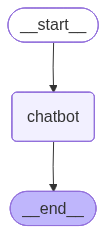

In [8]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

## Graph Invocation

In [9]:
ai_response = graph.invoke({"messages":"Hi"})

In [10]:
print(ai_response["messages"][-1].content)

Hello! How can I help you today?


In [11]:
for event in graph.stream({"messages":"Hi"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! How can I help you today?


### Chatbot with Tools

In [12]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=2)

search_tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.worldatlas.com/articles/what-is-the-capital-of-france.html',
   'title': 'What is the Capital of France? - World Atlas',
   'content': 'Paris is the capital city of France. The city has an approximate area of 41 square miles with a population of 2,206,488 people as of 2018. Contrary to popular belief, the name of the city did not come from the Paris in Greek myths. Instead, the name Paris is derived from the city’s initial inhabitants who were part of the Celtic Parisii tribe. Located in the north of Central France, the city is relatively flat with the highest point being 427 feet (which is Montmartre) above sea level while the lowest point is 115 feet above the sea level. With a GDP of approximately $850 billion, Paris is the country’s leader for economic activities. Tourists are attracted to Paris because of the rich history the city has includin

### Custom tools (functionality)

In [13]:
def multiply(a:int,b:int)->int:
    """_summary_

    Args:
        a (int): _description_
        b (int): _description_

    Returns:
        int: _description_
    """
    return a * b

In [14]:
tools = [search_tool,multiply]

In [15]:
# tools Binding with LLM
llm_with_tools = llm_model.bind_tools(tools)

In [16]:
llm_with_tools


_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DAE3AE31A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DAE3C4FCB0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers 

In [17]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph Building
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Adding Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)

# graph compilation
graph_with_tools = builder.compile()

### Graph Visualiztion

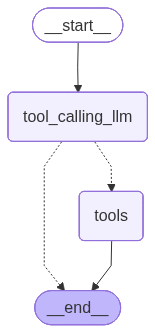

In [18]:
from IPython.display import display,Image

try:
    display(Image(graph_with_tools.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

### Graph Invocation

In [19]:
graph_with_tools.invoke({"messages":"What is the capital of France and what is 5 multiplied by 3?"})

{'messages': [HumanMessage(content='What is the capital of France and what is 5 multiplied by 3?', additional_kwargs={}, response_metadata={}, id='877c555f-e2e7-4961-9644-2d2aaa78fdff'),
  AIMessage(content='The capital of France is **Paris**, and \\(5 \\times 3 = 15\\).', additional_kwargs={'reasoning_content': 'User asks: "What is the capital of France and what is 5 multiplied by 3?" We need to answer both. Capital of France is Paris. 5 multiplied by 3 is 15. No need to search.'}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 356, 'total_tokens': 433, 'completion_time': 0.081867978, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.022813806, 'prompt_tokens_details': None, 'queue_time': 0.051544154, 'total_time': 0.104681784}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2cec-29ae-7611-add

In [20]:
graph_with_tools.invoke({"messages":"recently who won in west bengal elections?"})

{'messages': [HumanMessage(content='recently who won in west bengal elections?', additional_kwargs={}, response_metadata={}, id='55afe12a-84f0-4fb5-a1e9-bfcc7d49b1ee'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "recently who won in west bengal elections?" Likely refers to the recent West Bengal Legislative Assembly elections (2021) or maybe the 2024? As of 2026, the latest West Bengal election was 2021. The winner: All India Trinamool Congress (AITC) led by Mamata Banerjee. So answer: Mamata Banerjee\'s Trinamool Congress won. Provide details. Maybe include seat counts. Provide citations? Use search.', 'tool_calls': [{'id': 'fc_3790dcfa-1984-405b-8a1c-6b304ea685a2', 'function': {'arguments': '{"query":"West Bengal elections 2021 results","search_depth":"basic"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 350, 'total_tokens': 492, 'completion_time': 0.146818797,

In [21]:
response = graph_with_tools.invoke({"messages":"Multiply 2 and 3"})

In [22]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_d0266da2-45cb-47cd-96b4-9d20f81718e4)
 Call ID: fc_d0266da2-45cb-47cd-96b4-9d20f81718e4
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


## ReAct Architecture Agent
- Act
- Observe
- Reason

In [23]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph Building
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Adding Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# graph compilation
react_agent = builder.compile()

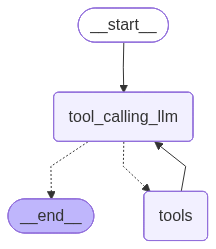

In [24]:
from IPython.display import display,Image

try:
    display(Image(react_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

## Adding Memory in Agentic Graph

In [25]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

agentic_memory = MemorySaver()

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph Building
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Adding Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# graph compilation
react_agent_with_memory = builder.compile(checkpointer=agentic_memory)

In [26]:
config ={"configurable":{"thread_id":"1"}}

In [27]:
ai_res = react_agent_with_memory.invoke({"messages":"Hi My name is Anupam"},config=config)

In [28]:
ai_res = react_agent_with_memory.invoke({"messages":"What is my Name?"},config=config)
print(ai_res["messages"][-1].content)

Your name is **Anupam**.


### Streaming Techniquies

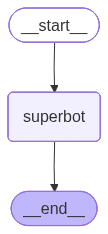

In [29]:
# Basic chatbot

graph = StateGraph(State)
def superbot(state:State):
    return {"messages":[llm_model.invoke(state["messages"])]}

# node definition
graph.add_node("superbot",superbot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder_ = graph.compile(checkpointer=agentic_memory)

try:
    display(Image(graph_builder_.get_graph().draw_mermaid_png()))
    
except Exception as e:
    print("Graph visualization failed:", e)




### Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [30]:
config ={"configurable":{"thread_id":"1"}}
for chunk in graph_builder_.stream({"messages":"Hi, My name is Anupam"},config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Anupam! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user repeats greeting. They might want conversation or something. According to policies, we should respond politely. No disallowed content. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 134, 'total_tokens': 185, 'completion_time': 0.056870646, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.013459287, 'prompt_tokens_details': None, 'queue_time': 0.051169118, 'total_time': 0.070329933}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2cec-36bd-7db1-840b-ae72677350f8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 134, 'output_tokens': 51, 'total_tokens': 185, 'output_token_details': {'reasoning': 30}})]}}


In [31]:
config ={"configurable":{"thread_id":"1"}}
for chunk in graph_builder_.stream({"messages":"Hi, My name is Anupam"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi My name is Anupam', additional_kwargs={}, response_metadata={}, id='1ac5c4a1-bff1-4438-be6d-534e625e6b10'), AIMessage(content='Hello Anupam! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hi My name is Anupam". Likely greeting. I can respond politely, ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 347, 'total_tokens': 397, 'completion_time': 0.051374547, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.018160082, 'prompt_tokens_details': None, 'queue_time': 0.054146473, 'total_time': 0.069534629}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2cec-342e-7b61-94f9-84d4f0670152-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 347, 'output_tokens': 50, 'total_tokens': 397, 'output